# Week 9 workshop · Entropy in the Week 1 Schelling model

<span class="workshop-download-enabled" aria-hidden="true"></span>

This workshop returns to the [Week 1 Schelling model](../week01/L_Introduction_to_complex_systems.ipynb). We will use the same states, neighbourhood, similarity rule and random relocation process.

The aim is to separate four questions that can otherwise sound alike:

- how uncertain is one variable?
- how uncertain are two variables together?
- how much uncertainty remains after observing one variable?
- how much does one variable tell us about the other?

## 1. Returning to our Week 1 model

The code below is the Week 1 model used in lectures. It uses a bounded 5 × 5 grid, empty/yellow/blue site states, an open Moore neighbourhood, a 50% similarity threshold and random relocation of one dissatisfied agent at each step and a mean similarity ratio as a summary of local values.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

EMPTY, YELLOW, BLUE = 0, 1, 2
GRID_SIZE = 5
STATE_PROBABILITIES = (0.15, 0.425, 0.425)
THRESHOLD = 0.50
SEED = 1
CMAP = ListedColormap(["white", "#EDCC55", "#5879AA"])

def entropy(weights):
    """Shannon entropy in bits from probabilities or non-negative weights."""
    p = np.asarray(weights, dtype=float)
    if p.ndim != 1 or p.size == 0 or not np.all(np.isfinite(p)) or np.any(p < 0):
        raise ValueError("Give a non-empty vector of finite, non-negative weights")
    if p.sum() <= 0:
        raise ValueError("The weights must have a positive total")
    p = p / p.sum()
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def initialise(seed=SEED):
    rng = np.random.default_rng(seed)
    return rng.choice([EMPTY, YELLOW, BLUE], size=(GRID_SIZE, GRID_SIZE),
                      p=STATE_PROBABILITIES)

def neighbourhood(grid, row, col):
    return grid[max(0, row - 1):min(grid.shape[0], row + 2),
                max(0, col - 1):min(grid.shape[1], col + 2)]

def similarity_ratios(grid):
    values = []
    for row, col in zip(*np.where(grid != EMPTY)):
        local = neighbourhood(grid, row, col)
        occupied = np.count_nonzero(local) - 1
        if occupied:
            similar = np.count_nonzero(local == grid[row, col]) - 1
            values.append(similar / occupied)
    return np.asarray(values, dtype=float)

def dissatisfied(grid, threshold=THRESHOLD):
    bad = []
    for row, col in zip(*np.where(grid != EMPTY)):
        local = neighbourhood(grid, row, col)
        occupied = np.count_nonzero(local) - 1
        ratio = 0 if occupied == 0 else (np.count_nonzero(local == grid[row, col]) - 1) / occupied
        if ratio < threshold:
            bad.append((row, col))
    return bad

def run_schelling(initial, seed=SEED, threshold=THRESHOLD, max_steps=200):
    rng = np.random.default_rng(seed)
    grid = initial.copy()
    frames = [grid.copy()]
    msr = [float(np.mean(similarity_ratios(grid)))]
    dissatisfied_count = [len(dissatisfied(grid, threshold))]
    for _ in range(max_steps):
        unhappy = dissatisfied(grid, threshold)
        empty = np.argwhere(grid == EMPTY)
        if not unhappy or not len(empty):
            break
        row, col = unhappy[rng.integers(len(unhappy))]
        new_row, new_col = empty[rng.integers(len(empty))]
        grid[new_row, new_col], grid[row, col] = grid[row, col], EMPTY
        frames.append(grid.copy())
        msr.append(float(np.mean(similarity_ratios(grid))))
        dissatisfied_count.append(len(dissatisfied(grid, threshold)))
    return frames, np.asarray(msr), np.asarray(dissatisfied_count)

initial = initialise(SEED)
frames, msr, dissatisfied_count = run_schelling(initial, seed=SEED)
final = frames[-1]
print(f"Recorded {len(frames) - 1} successful moves.")
print(f"Mean similarity ratio: {msr[0]:.3f} → {msr[-1]:.3f}")
print(f"Dissatisfied agents: {dissatisfied_count[0]} → {dissatisfied_count[-1]}")

Recorded 16 successful moves.
Mean similarity ratio: 0.435 → 0.877
Dissatisfied agents: 12 → 0


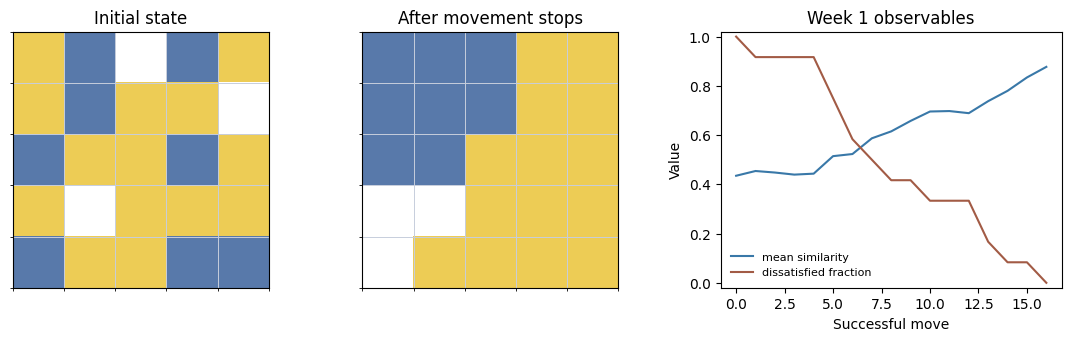

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3), constrained_layout=True)
for ax, grid, title in zip(axes[:2], (initial, final), ("Initial state", "After movement stops")):
    ax.imshow(grid, cmap=CMAP, vmin=0, vmax=2)
    ax.set(title=title, xticks=[], yticks=[])
    ax.set_xticks(np.arange(-.5, GRID_SIZE, 1), minor=True)
    ax.set_yticks(np.arange(-.5, GRID_SIZE, 1), minor=True)
    ax.grid(which="minor", color="#C7CEDC", linewidth=.7)
axes[2].plot(msr, color="#3978A8", label="mean similarity")
axes[2].plot(dissatisfied_count / max(1, dissatisfied_count[0]), color="#A25B45", label="dissatisfied fraction")
axes[2].set(xlabel="Successful move", ylabel="Value", ylim=(-.02, 1.02), title="Week 1 observables")
axes[2].legend(frameon=False, fontsize=8)
plt.show()

## 2. Entropy of one variable

Define two single-variable observations from each grid:

- $X$: the group of a randomly selected occupied agent;
- $S$: that agent's local similarity, placed into five equal-width bins.

$H(X)$ describes uncertainty about group labels. $H(S)$ describes how broadly local similarity values occupy the five bins; the mean similarity gives only their average level. Here $H(S)$ falls from $1.920$ to $1.096$ bits while mean $S$ rises from $0.435$ to $0.877$.

state                 H(X)      H(S)      mean S
initial             0.946     1.920     0.435
final               0.946     1.096     0.877


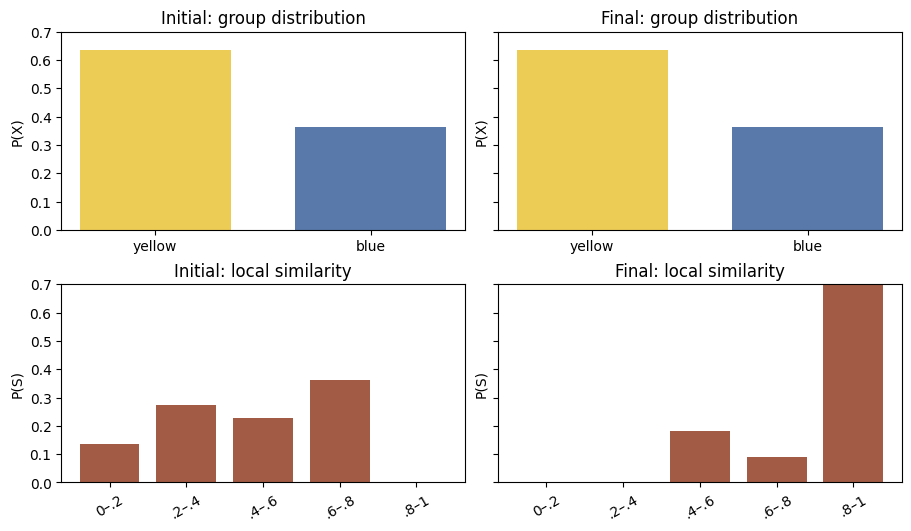

In [3]:
def group_probabilities(grid):
    counts = np.bincount(grid[grid != EMPTY].astype(int), minlength=3)[1:]
    return counts / counts.sum()

def similarity_probabilities(grid, bins=5):
    values = similarity_ratios(grid)
    counts, _ = np.histogram(values, bins=np.linspace(0, 1, bins + 1))
    return counts / counts.sum()

def marginal_summary(grid):
    p_x = group_probabilities(grid)
    p_s = similarity_probabilities(grid)
    return entropy(p_x), entropy(p_s), float(np.mean(similarity_ratios(grid)))

print("state                 H(X)      H(S)      mean S")
for label, grid in (("initial", initial), ("final", final)):
    hx, hs, mean_s = marginal_summary(grid)
    print(f"{label:10s}          {hx:5.3f}     {hs:5.3f}     {mean_s:5.3f}")

fig, axes = plt.subplots(2, 2, figsize=(9, 5.2), sharey="row", constrained_layout=True)
for col, (grid, title) in enumerate(zip((initial, final), ("Initial", "Final"))):
    group_ax, similarity_ax = axes[:, col]
    group_ax.bar([0, 1], group_probabilities(grid), width=.7, color=["#EDCC55", "#5879AA"])
    group_ax.set(xticks=[0, 1], xticklabels=["yellow", "blue"], ylim=(0, .7),
                 ylabel="P(X)", title=f"{title}: group distribution")
    similarity_ax.bar(np.arange(5), similarity_probabilities(grid), width=.78,
                     color="#A25B45")
    similarity_ax.set(xticks=np.arange(5),
                     xticklabels=["0–.2", ".2–.4", ".4–.6", ".6–.8", ".8–1"],
                     ylim=(0, .7), ylabel="P(S)", title=f"{title}: local similarity")
    similarity_ax.tick_params(axis="x", rotation=30)
plt.show()

**Questions.**

1. Why does $H(X)$ not change when the grid segregates?
2. What does $H(S)$ capture that the mean similarity ratio does not?
3. What modelling choices contribute to the value of $H(S)$?

## 3. Joint, conditional and mutual information

Choose uniformly from occupied focal agents that have at least one occupied neighbour, then choose one of those neighbours uniformly. Let $X$ be the focal group and $Y$ the neighbour group. The four pair types form a joint distribution.

The printed table and the coloured squares are two views of the same joint distribution. Rows are focal group $X$, columns are neighbour group $Y$, and each cell is $P(X=x,Y=y)$. Colour shows the cell magnitude; the labels show the same values.

From those four cells we calculate $H(X)$, $H(Y)$, $H(X,Y)$, $H(Y\mid X)$ and $I(X;Y)$.


initial focal–neighbour probabilities
P(X,Y): rows = focal X; columns = neighbour Y
             Y=yellow  Y=blue
X=yellow    0.375   0.262
X=blue      0.304   0.060
H(X)      H(Y)      H(X,Y)    H(Y | X)  I(X;Y)
  0.946   0.906   1.802   0.857   0.049

final focal–neighbour probabilities
P(X,Y): rows = focal X; columns = neighbour Y
             Y=yellow  Y=blue
X=yellow    0.575   0.061
X=blue      0.062   0.302
H(X)      H(Y)      H(X,Y)    H(Y | X)  I(X;Y)
  0.946   0.945   1.475   0.530   0.416


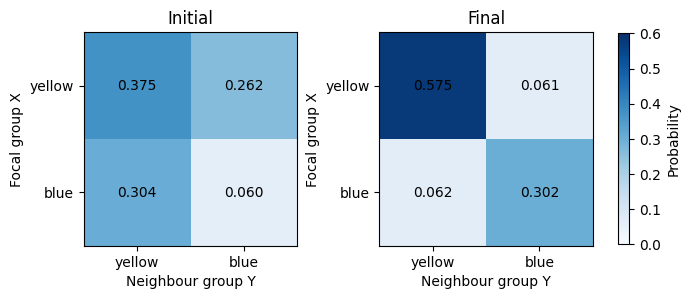

In [4]:
def focal_neighbour_joint(grid):
    counts = np.zeros((2, 2), dtype=float)
    focal_sites = list(zip(*np.where(grid != EMPTY)))
    for row, col in focal_sites:
        neighbours = [(nrow, ncol)
                      for nrow in range(max(0, row - 1), min(grid.shape[0], row + 2))
                      for ncol in range(max(0, col - 1), min(grid.shape[1], col + 2))
                      if (nrow, ncol) != (row, col) and grid[nrow, ncol] != EMPTY]
        if not neighbours:
            continue
        focal_weight = 1 / len(focal_sites)
        for nrow, ncol in neighbours:
            counts[grid[row, col] - 1, grid[nrow, ncol] - 1] += focal_weight / len(neighbours)
    return counts / counts.sum()

def pair_summary(grid):
    joint = focal_neighbour_joint(grid)
    p_x, p_y = joint.sum(axis=1), joint.sum(axis=0)
    h_x, h_y = entropy(p_x), entropy(p_y)
    h_xy = entropy(joint.ravel())
    h_y_given_x = h_xy - h_x
    mutual_information = h_y - h_y_given_x
    return joint, (h_x, h_y, h_xy, h_y_given_x, mutual_information)

for label, grid in (("initial", initial), ("final", final)):
    joint, values = pair_summary(grid)
    print(f"\n{label} focal–neighbour probabilities")
    print("P(X,Y): rows = focal X; columns = neighbour Y")
    print("             Y=yellow  Y=blue")
    for group, row in zip(("yellow", "blue"), joint):
        print(f"X={group:<6}    " + "   ".join(f"{value:.3f}" for value in row))
    print("H(X)      H(Y)      H(X,Y)    H(Y | X)  I(X;Y)")
    print("  " + "   ".join(f"{value:5.3f}" for value in values))

fig, axes = plt.subplots(1, 2, figsize=(6.8, 3), constrained_layout=True)
for ax, grid, title in zip(axes, (initial, final), ("Initial", "Final")):
    joint, _ = pair_summary(grid)
    image = ax.imshow(joint, vmin=0, vmax=.6, cmap="Blues")
    ax.set(title=title, xlabel="Neighbour group Y", ylabel="Focal group X",
           xticks=[0, 1], xticklabels=["yellow", "blue"],
           yticks=[0, 1], yticklabels=["yellow", "blue"])
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f"{joint[row, col]:.3f}", ha="center", va="center")
fig.colorbar(image, ax=axes, shrink=.8, label="Probability")
plt.show()

**Questions.**

1. Does segregation mainly change the marginal group probabilities, or the relationship between neighbouring groups?
2. $H(Y\mid X)$ is the uncertainty about a neighbour after the focal group is known. How does it compare with $H(Y)$?
3. Check the identity $I(X;Y)=H(Y)-H(Y\mid X)$ is satisfied. What does the increase in $I(X;Y)$ say about the Schelling mechanism?
4. Why can $H(X)$ stay almost fixed while $I(X;Y)$ changes?

## 4. How does entropy evolve through the run?

Track each entropy measure from initialisation, though every recorded state to the final one. Keep the binning rule fixed while the simulation evolves.

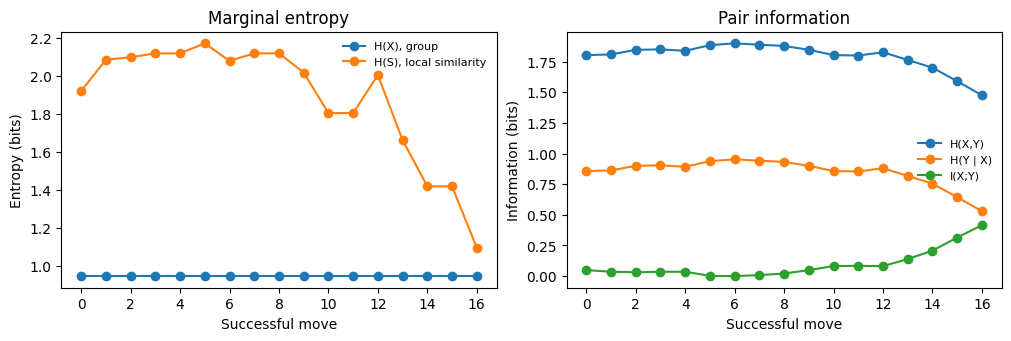

In [5]:
time_measures = {
    "H(X)": [],
    "H(S)": [],
    "H(X,Y)": [],
    "H(Y | X)": [],
    "I(X;Y)": [],
}
for grid in frames:
    hx, hs, _ = marginal_summary(grid)
    _, (_, _, hxy, hy_x, mi) = pair_summary(grid)
    time_measures["H(X)"].append(hx)
    time_measures["H(S)"].append(hs)
    time_measures["H(X,Y)"].append(hxy)
    time_measures["H(Y | X)"].append(hy_x)
    time_measures["I(X;Y)"].append(mi)

steps = np.arange(len(frames))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3), constrained_layout=True)
axes[0].plot(steps, time_measures["H(X)"], "o-", label="H(X), group")
axes[0].plot(steps, time_measures["H(S)"], "o-", label="H(S), local similarity")
axes[0].set(xlabel="Successful move", ylabel="Entropy (bits)", title="Marginal entropy")
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(steps, time_measures["H(X,Y)"], "o-", label="H(X,Y)")
axes[1].plot(steps, time_measures["H(Y | X)"], "o-", label="H(Y | X)")
axes[1].plot(steps, time_measures["I(X;Y)"], "o-", label="I(X;Y)")
axes[1].set(xlabel="Successful move", ylabel="Information (bits)", title="Pair information")
axes[1].legend(frameon=False, fontsize=8)
plt.show()

## 5. How does entropy change with a model parameter?

Now hold the initial grid fixed and vary the similarity threshold. This controlled comparison asks how the relocation rule changes the final distributions. The entropy of $S$ is divided by its five-bin maximum so it can be compared with the mean similarity ratio and mutual information on the same scale. Check whether each run settles before interpreting its endpoint.

threshold   moves   settled    MSR    H(S)/max   I(X;Y)
    0.20       4   True      0.529     0.831      0.000
    0.35      34   True      0.746     0.619      0.142
    0.50      16   True      0.877     0.472      0.416
    0.65     179   True      0.904     0.364      0.491
    0.80     200   False     0.551     0.793      0.002


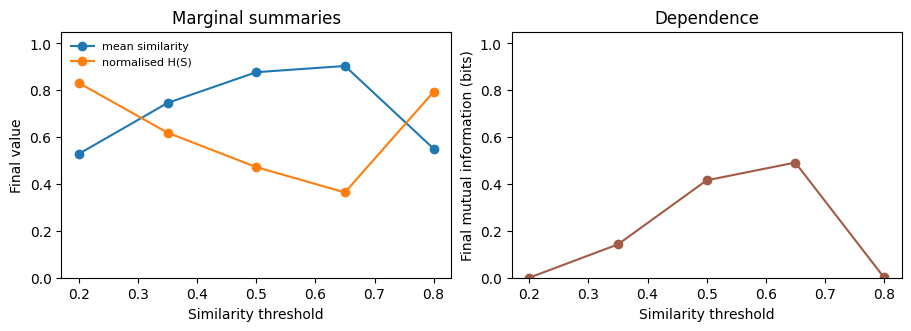

In [6]:
thresholds = np.array([0.20, 0.35, 0.50, 0.65, 0.80])
parameter_results = []
for threshold in thresholds:
    threshold_frames, _, threshold_dissatisfied = run_schelling(initial, seed=SEED, threshold=threshold)
    state = threshold_frames[-1]
    _, (_, _, _, _, mi) = pair_summary(state)
    parameter_results.append({
        "threshold": threshold,
        "moves": len(threshold_frames) - 1,
        "settled": threshold_dissatisfied[-1] == 0,
        "MSR": float(np.mean(similarity_ratios(state))),
        "H(S)/max": entropy(similarity_probabilities(state)) / np.log2(5),
        "I(X;Y)": mi,
    })

print("threshold   moves   settled    MSR    H(S)/max   I(X;Y)")
for result in parameter_results:
    print(f"{result['threshold']:8.2f}   {result['moves']:5d}   {str(result['settled']):7s}   {result['MSR']:.3f}     {result['H(S)/max']:.3f}      {result['I(X;Y)']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharex=True, constrained_layout=True)
axes[0].plot(thresholds, [r["MSR"] for r in parameter_results], "o-", label="mean similarity")
axes[0].plot(thresholds, [r["H(S)/max"] for r in parameter_results], "o-", label="normalised H(S)")
axes[0].set(xlabel="Similarity threshold", ylabel="Final value", ylim=(0, 1.05), title="Marginal summaries")
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(thresholds, [r["I(X;Y)"] for r in parameter_results], "o-", color="#A25B45")
axes[1].set(xlabel="Similarity threshold", ylabel="Final mutual information (bits)", ylim=(0, 1.05), title="Dependence")
plt.show()

## 6. How does entropy change with bin size?

The local similarity values are unchanged, but changing the bins changes the variable being measured and hence, changes the entropy. Compare three, five and ten bins.

In [7]:
print("bins    H(S)")
for bins in (3, 5, 10):
    print(f"{bins:4d}   {entropy(similarity_probabilities(final, bins)):5.3f} bits")

# Change the seed or threshold, rerun the model, and compare the same summaries.
# Keep the definitions of X, Y and S fixed while you compare runs.

bins    H(S)
   3   0.684 bits
   5   1.096 bits
  10   1.693 bits


## 7. What else would be useful to compare? 

Choose one change to the model or sampling rule and predict which measure should respond. Possibilities include a different random seed, group balance, neighbourhood radius, grid size, stopping rule or distance between paired agents. Explain what would count as evidence for your prediction.